## Import Modules & Data

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier

from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

import xgboost as xgb
import lightgbm as lgb


import warnings
warnings.filterwarnings('ignore')


In [3]:
#Load the dataset
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

#View the dataset
train_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Initial Exploratory Data Analysis

In [3]:
# View the first few rows of the dataset
train_df.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train_df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
train_df.shape

(891, 12)

In [6]:

# Get information about the dataset
train_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
# Generate summary statistics
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Visualization

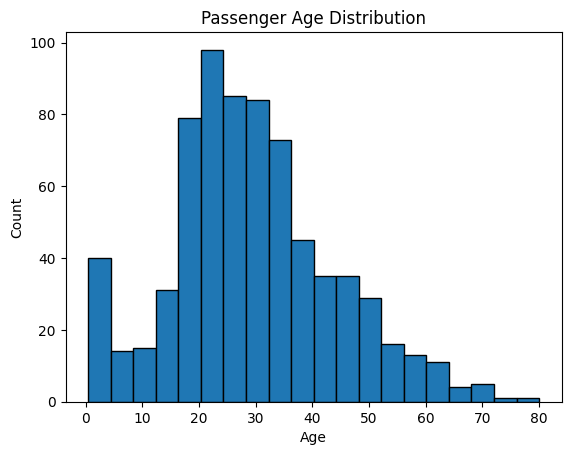

In [8]:
# Histogram of passenger ages
plt.hist(train_df["Age"].dropna(), bins=20, edgecolor="k")
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Passenger Age Distribution")
plt.show()

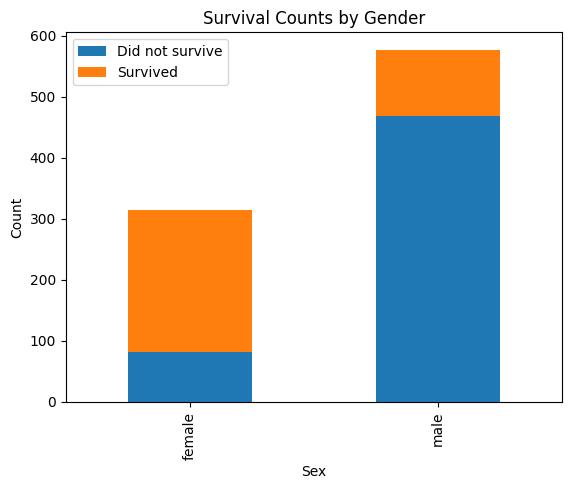

In [9]:
# Bar chart of survival counts based on gender
survived_by_gender = train_df.groupby("Sex")["Survived"].value_counts().unstack()
survived_by_gender.plot(kind="bar", stacked=True)
plt.xlabel("Sex")
plt.ylabel("Count")
plt.title("Survival Counts by Gender")
plt.legend(["Did not survive", "Survived"])
plt.show()

## Missing Data

In [10]:
# Calculate percentage of missing values
missing_percentage = train_df.isnull().sum() / len(train_df) * 100

# Print columns with missing values and their corresponding percentages
print(missing_percentage[missing_percentage > 0])

Age         19.865320
Cabin       77.104377
Embarked     0.224467
dtype: float64


Since the 'Cabin' column has over 77% missing values, it seems more reasonable to drop this collumn alltogether. For 'Age' and 'Embarked' we can impute a value, e.g. the mean or median (to lessen impact of outliers).

In [4]:
train_df.drop(['Cabin'], axis=1, inplace=True)
test_df.drop(['Cabin'], axis=1, inplace=True)

In [5]:
imputer = SimpleImputer(strategy="median")  # Use median for numerical features
train_df["Age"] = imputer.fit_transform(train_df[["Age"]]).ravel()  # Fill missing Age values with median
test_df["Age"] = imputer.fit_transform(test_df[["Age"]]).ravel()


In [13]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


## Remove Unique Values Columns

In [14]:
# Check for columns with unique values
columns_with_unique_values = []
for column in train_df.columns:
    if train_df[column].nunique() == len(train_df):
        columns_with_unique_values.append(column)

# Print the columns with unique values
print("Columns with unique values:", columns_with_unique_values)

Columns with unique values: ['PassengerId', 'Name']


In [6]:
train_df.drop(['PassengerId'], axis=1, inplace=True) # We'll remove 'Name' later after we've extracted some feature information.

In [16]:
# # Calculate the percentage of unique values in the 'Ticket' column
# unique_tickets = train_df['Ticket'].nunique()
# total_tickets = train_df['Ticket'].count()
# percentage_unique_tickets = (unique_tickets / total_tickets) * 100

# # Print the percentage of unique tickets
# print("Percentage of unique tickets: {:.2f}%".format(percentage_unique_tickets))


Most of the values in the 'Ticket' column is unique as well. Let's remove it.

In [7]:
train_df.drop(['Ticket'], axis=1, inplace=True)
test_df.drop(['Ticket'], axis=1, inplace=True)

## Correlation Analysis

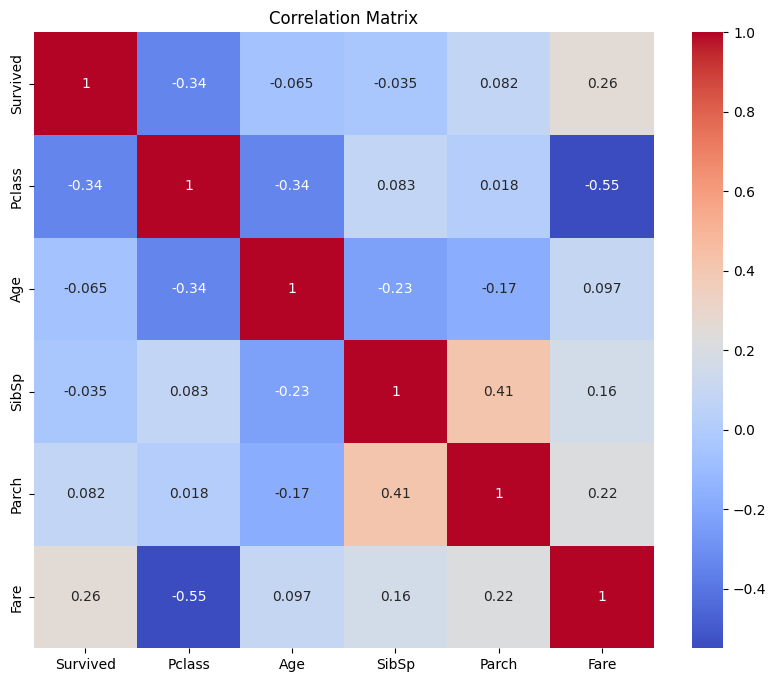

In [18]:
# Create a correlation matrix
numerical_df = train_df.select_dtypes(include=['number'])
correlation_matrix = numerical_df.corr()
# Generate a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Survival Analysis

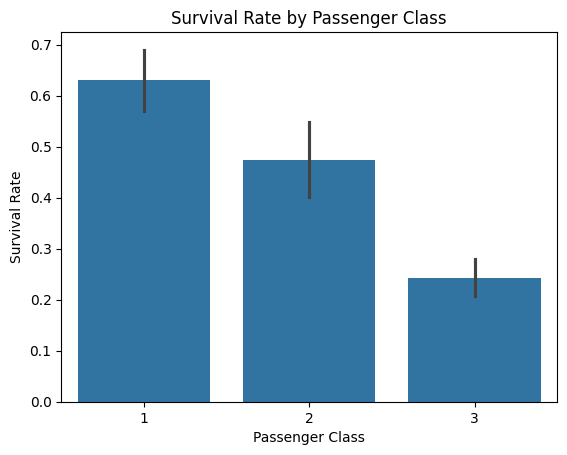

In [19]:
# Calculate survival rate by passenger class
survival_by_class = train_df.groupby("Pclass")["Survived"].mean()

# Bar chart of survival rate by passenger class
sns.barplot(x="Pclass", y="Survived", data=train_df)
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Passenger Class")
plt.show()

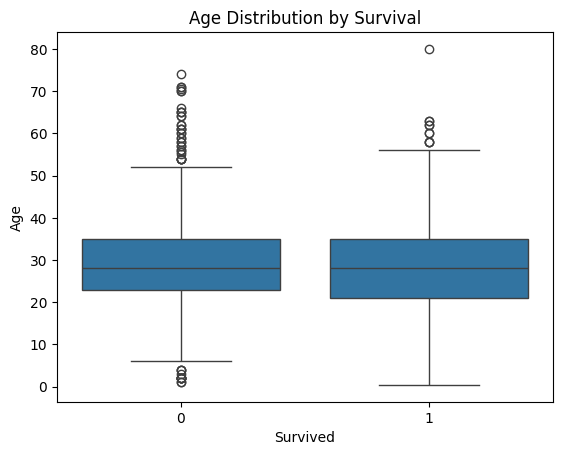

In [20]:
# Box plot of age distribution by survival
sns.boxplot(x="Survived", y="Age", data=train_df)
plt.xlabel("Survived")
plt.ylabel("Age")
plt.title("Age Distribution by Survival")
plt.show()

## Feature Engineering

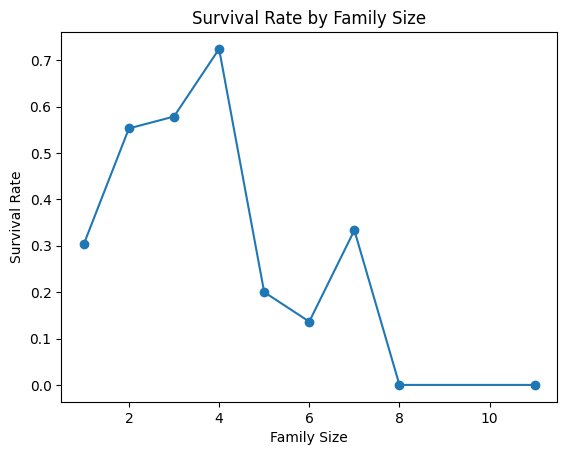

In [8]:
# Create a new feature for family size
train_df["FamilySize"] = train_df["SibSp"] + train_df["Parch"] + 1
test_df["FamilySize"] = test_df["SibSp"] + test_df["Parch"] + 1

# Calculate survival rate by family size
survival_by_family_size = train_df.groupby("FamilySize")["Survived"].mean()

# Line plot of survival rate by family size
plt.plot(survival_by_family_size.index, survival_by_family_size.values, marker="o")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Family Size")
plt.show()

In [9]:
# # Extract the titles from the 'Name' column using regular expressions
# train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Create bins for age groups
bins = [0, 12, 18, 30, 50, 200]  # Adjust the age ranges as desired
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
train_df['AgeGroup'] = pd.cut(train_df['Age'], bins=bins, labels=labels)
test_df['AgeGroup'] = pd.cut(test_df['Age'], bins=bins, labels=labels)

# Create bins for fare groups
bins = [0, 10, 30, 1000]  # Adjust the fare ranges as desired
labels = ['Low', 'Medium', 'High']
train_df['FareGroup'] = pd.cut(train_df['Fare'], bins=bins, labels=labels)
test_df['FareGroup'] = pd.cut(test_df['Fare'], bins=bins, labels=labels)

train_df.drop(['Name'], axis=1, inplace=True)
test_df.drop(['Name'], axis=1, inplace=True)

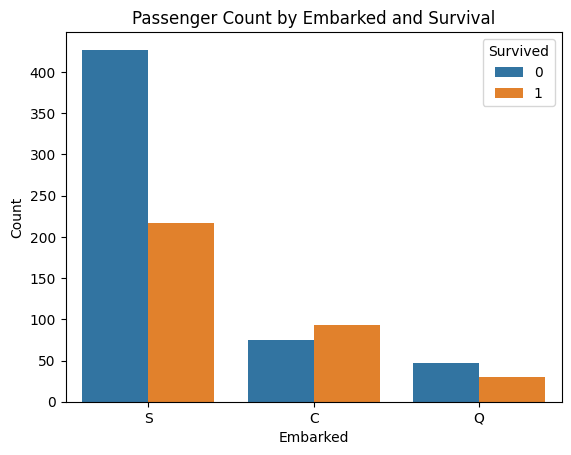

In [23]:
# Countplot of embarkation point and survival
sns.countplot(x="Embarked", hue="Survived", data=train_df)
plt.xlabel("Embarked")
plt.ylabel("Count")
plt.title("Passenger Count by Embarked and Survival")
plt.show()

## Encode Categorical Data

In [10]:
encoder = OneHotEncoder(drop="first")  # Drop first category to avoid multicollinearity
encoded_features = pd.DataFrame(encoder.fit_transform(train_df[[
    "Sex",
    "Embarked",
    "AgeGroup",
    "FareGroup"
]]).toarray(),
  columns=encoder.get_feature_names_out([
      "Sex",
      "Embarked",
      "AgeGroup",
      "FareGroup"
  ]))
df_encoded = pd.concat([train_df, encoded_features], axis=1)

df_encoded.drop([
    'Sex',
    'Embarked',
    "AgeGroup",
    "FareGroup"
], axis=1, inplace=True)

In [25]:
df_encoded.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S,Embarked_nan,AgeGroup_Child,AgeGroup_Senior,AgeGroup_Teen,AgeGroup_Young Adult,FareGroup_Low,FareGroup_Medium,FareGroup_nan
0,0,3,22.0,1,0,7.2500,2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,1,1,38.0,1,0,71.2833,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,3,26.0,0,0,7.9250,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,1,1,35.0,1,0,53.1000,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,3,35.0,0,0,8.0500,1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [26]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Survived              891 non-null    int64  
 1   Pclass                891 non-null    int64  
 2   Age                   891 non-null    float64
 3   SibSp                 891 non-null    int64  
 4   Parch                 891 non-null    int64  
 5   Fare                  891 non-null    float64
 6   FamilySize            891 non-null    int64  
 7   Sex_male              891 non-null    float64
 8   Embarked_Q            891 non-null    float64
 9   Embarked_S            891 non-null    float64
 10  Embarked_nan          891 non-null    float64
 11  AgeGroup_Child        891 non-null    float64
 12  AgeGroup_Senior       891 non-null    float64
 13  AgeGroup_Teen         891 non-null    float64
 14  AgeGroup_Young Adult  891 non-null    float64
 15  FareGroup_Low         891 non-null

## Models

In [11]:
# Separate the features (X) and target variable (y)
X = df_encoded.drop("Survived", axis=1)
y = df_encoded["Survived"]

### Logistic Regression

In [28]:
# Instantiate the model
lr_model = LogisticRegression()

# Perform 5-fold cross-validation
scores = cross_val_score(lr_model, X, y, cv=5)

# Print the cross-validation scores
print("Cross-validation scores:", scores)
print("Mean cross-validation score:", scores.mean())

Cross-validation scores: [0.79888268 0.78089888 0.79213483 0.76966292 0.8258427 ]
Mean cross-validation score: 0.7934844014813885


### Multiple Models and Hyperparameter Tuning

In [12]:
trained_models = []

# Define parameter spaces for each model (reduced for speed)
param_spaces = {
    'LogisticRegression': {
        'C': Real(1e-2, 1e2, prior='log-uniform'),
    },
    'RandomForest': {
        'n_estimators': Integer(50, 200),
        'max_depth': Integer(3, 20),
    },
    'GradientBoosting': {
        'n_estimators': Integer(50, 200),
        'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
        'max_depth': Integer(2, 10),
    },
    'XGBoost': {
        'n_estimators': Integer(50, 200),
        'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
        'max_depth': Integer(2, 10),
    },
    'LightGBM': {
        'n_estimators': Integer(50, 200),
        'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
        'num_leaves': Integer(10, 50),
    }
}

# Define models (removed SVC and MLP for speed)
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1)
}

model_scores = {}
best_params_all = {}

# Perform Bayesian optimization for each model
for model_name, base_model in models.items():
    print(f"Optimizing {model_name}...")

    bayes_cv = BayesSearchCV(
        estimator=base_model,
        search_spaces=param_spaces[model_name],
        n_iter=10,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        random_state=42
    )

    bayes_cv.fit(X, y)

    best_model = bayes_cv.best_estimator_
    model_scores[model_name] = bayes_cv.best_score_
    best_params_all[model_name] = bayes_cv.best_params_

    scores = cross_val_score(best_model, X, y, cv=5, scoring='accuracy')

    print(f"  Best parameters: {bayes_cv.best_params_}")
    print(f"  Mean CV score: {scores.mean():.4f}")
    print()

best_model_name = max(model_scores, key=model_scores.get)
worst_model_name = min(model_scores, key=model_scores.get)

print(f"Best Model: {best_model_name} ({model_scores[best_model_name]:.4f})")
print(f"Worst Model: {worst_model_name} ({model_scores[worst_model_name]:.4f})")
print()

# Create ensemble from best params
trained_models = []
for name in models.keys():
    model_clone = type(models[name])(**models[name].get_params())
    model_clone.set_params(**best_params_all[name])
    trained_models.append((name, model_clone))

ensemble = VotingClassifier(trained_models)
ensemble_scores = cross_val_score(ensemble, X, y, cv=5, scoring='accuracy')
print(f"Ensemble Mean CV score: {ensemble_scores.mean():.4f}")


Optimizing LogisticRegression...
  Best parameters: OrderedDict({'C': 0.4369339947510315})
  Mean CV score: 0.8013

Optimizing RandomForest...
  Best parameters: OrderedDict({'max_depth': 10, 'n_estimators': 159})
  Mean CV score: 0.8305

Optimizing GradientBoosting...
  Best parameters: OrderedDict({'learning_rate': 0.15849201309311142, 'max_depth': 3, 'n_estimators': 140})
  Mean CV score: 0.8294

Optimizing XGBoost...
  Best parameters: OrderedDict({'learning_rate': 0.045401641878176635, 'max_depth': 9, 'n_estimators': 66})
  Mean CV score: 0.8373

Optimizing LightGBM...
  Best parameters: OrderedDict({'learning_rate': 0.045401641878176635, 'n_estimators': 188, 'num_leaves': 14})
  Mean CV score: 0.8384

Best Model: LightGBM (0.8384)
Worst Model: LogisticRegression (0.8013)

Ensemble Mean CV score: 0.8429


## Submit on Test

### Preprocess Test Data

In [ ]:
test_df.info()

In [ ]:
# Calculate percentage of missing values
missing_percentage = test_df.isnull().sum() / len(test_df) * 100

# Print columns with missing values and their corresponding percentages
print(missing_percentage[missing_percentage > 0])

'Fare' has missing data in the Test set, while it didn't in Train. Let's impute using the average.

In [13]:
imputer = SimpleImputer(strategy="mean")  # Use mean for numerical features
test_df["Fare"] = imputer.fit_transform(test_df[["Fare"]]).ravel()  # Fill missing Age values with mean
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  418 non-null    int64   
 1   Pclass       418 non-null    int64   
 2   Sex          418 non-null    str     
 3   Age          418 non-null    float64 
 4   SibSp        418 non-null    int64   
 5   Parch        418 non-null    int64   
 6   Fare         418 non-null    float64 
 7   Embarked     418 non-null    str     
 8   FamilySize   418 non-null    int64   
 9   AgeGroup     418 non-null    category
 10  FareGroup    415 non-null    category
dtypes: category(2), float64(2), int64(5), str(2)
memory usage: 30.7 KB


In [14]:
encoder = OneHotEncoder(drop="first")
encoded_features = pd.DataFrame(encoder.fit_transform(test_df[[
    "Sex",
    "Embarked",
    "AgeGroup",
    "FareGroup"
]]).toarray(),
  columns=encoder.get_feature_names_out([
    "Sex",
    "Embarked",
    "AgeGroup",
    "FareGroup"
                                ]))
test_df_encoded = pd.concat([test_df, encoded_features], axis=1)

test_df_encoded.drop([
    'Sex',
    'Embarked',
    "AgeGroup",
    "FareGroup"
], axis=1, inplace=True)




'Embarked' didn't have any missing values in Test, while it did in Train. The encoder will therefore not add an 'Embarked_nan' column. Since both our Train and Test df have to match when predicting on Test, let's add the column manually and fill it with 0s.


In [15]:

test_df_encoded.insert(test_df_encoded.columns.get_loc('Embarked_S') + 1, 'Embarked_nan', 0)


In [ ]:
test_df_encoded.head()

In [16]:
# Separate the features (X_test) and 'PassengerId'
X_test = test_df_encoded.drop("PassengerId", axis=1)

### Fit & Predict

In [19]:
# Recreate ensemble from tuned models
ensemble = VotingClassifier(trained_models)
ensemble.fit(X, y)


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('LogisticRegression', ...), ('RandomForest', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.4369339947510315
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [20]:
# Make predictions on the test data
predictions = ensemble.predict(X_test)


## Submission

In [21]:
# Create a DataFrame with 'PassengerId' and 'Survived' columns
submission_df = pd.DataFrame({'PassengerId': test_df['PassengerId'], 'Survived': predictions})
submission_df.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


In [22]:
# Save the predictions to a CSV file
submission_df.to_csv("submission.csv", index=False)